## Refold Complex

### Refold with target templates

In [1]:
# import functions
import numpy as np
import jax
import re
import os
import json
import pyrosetta as pr
import pandas as pd
from Bio import PDB
from Bio.PDB import PDBIO, Select
from Bio.SeqUtils import seq1
from DockQ.DockQ import load_PDB, run_on_all_native_interfaces
from colabdesign import mk_af_model, clear_mem
from colabdesign.shared.utils import copy_dict
from functions.pyrosetta_utils import pr_relax, unaligned_rmsd, align_pdbs
from functions.biopython_utils import target_pdb_rmsd

from myScripts.complexRefold import predict_complex, predict_binder, SelectChain, separate_complex
pr.init('-ignore_unrecognized_res -ignore_zero_occupancy -mute all -holes:dalphaball /hpf/projects/mtyers/ningrui/NXBindCraft/functions/DAlphaBall.gcc -corrections::beta_nov16 true -relax:default_repeats 1')


┌──────────────────────────────────────────────────────────────────────────────┐
│                                 PyRosetta-4                                  │
│              Created in JHU by Sergey Lyskov and PyRosetta Team              │
│              (C) Copyright Rosetta Commons Member Institutions               │
│                                                                              │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRE PURCHASE OF A LICENSE │
│         See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└──────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2025 [Rosetta PyRosetta4.conda.ubuntu.cxx11thread.serialization.Ubuntu.python310.Release 2025.06+release.029c6a159b896477003a14f78f472d4cd2cead46 2025-02-04T15:14:13] retrieved from: http://www.pyrosetta.org


In [9]:
main_folder = '/hpf/projects/mtyers/ningrui/NXBindCraft'
trial_name = 'testRefold'
params_path = '/hpf/projects/mtyers/ningrui//BindCraft'


In [ ]:
num_recycles_validation = 3
multimer_validation = False
predict_initial_guess = False
predict_bigbang = False
rm_template_seq_predict = False
rm_template_sc_predict = False
complex_prediction_models = [0,1]
binder_prediction_models = [0,1,2,3,4]

filter_name = 'default_filters.json'
filter_path = os.path.join('/hpf/projects/mtyers/ningrui/NXBindCraft/settings_filters', filter_name)
with open(filter_path, 'r') as file:
    filters = json.load(file)


In [30]:
#complex_list = ['5zng', '6a6i', '6gs2', '6h4b', '6if2']
target_path = '/hpf/projects/mtyers/ningrui/NXBindCraft/myTrials/testRefold/Targets'
file_names = os.listdir(target_path)
complex_list = list(set([t[:4] for t in file_names]))

rmsds = ['HotspotRMSD', 'Target_RMSD', 'Binder_RMSD', 'Pred_Binder_RMSD', 'DockQ', 'Pass_base_af2_filters', 'Best_complex_model', 'Best_binder_model']
rmsd_df = pd.DataFrame(index=complex_list, columns=rmsds)
rmsd_df

,HotspotRMSD,Target_RMSD,Binder_RMSD,Pred_Binder_RMSD,DockQ,Pass_base_af2_filters,Best_complex_model,Best_binder_model
6u08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5zng,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6a6i,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7nlj,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7aye,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6q76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6if2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7d2t,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7m5f,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6pnq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
for complex_name in complex_list:
    target_pdb, binder_seq, target_chain, binder_chain = separate_complex(complex_name)
    gt_complex_pdb = os.path.join(main_folder, 'myTrials/testRefold/Targets', complex_name+'.pdb')
    print(f'Complex: {complex_name}')

    clear_mem()
    # compile complex prediction model
    complex_prediction_model = mk_af_model(protocol = 'binder',
                                        num_recycles = num_recycles_validation,
                                        data_dir = params_path,
                                        use_multimer = multimer_validation,
                                        use_initial_guess = predict_initial_guess,
                                        use_initial_atom_pos = predict_bigbang)

    complex_prediction_model.prep_inputs(pdb_filename=target_pdb, 
                                     chain=target_chain, 
                                     binder_len=len(binder_seq),
                                     rm_target_seq=rm_template_seq_predict, 
                                     rm_target_sc=rm_template_sc_predict)
    print('Finish prepare complex model')
    
    # compile binder monomer prediction model
    binder_prediction_model = mk_af_model(protocol='hallucination',
                                      use_templates = False,
                                      initial_guess=False,
                                      use_initial_atom_pos=False,
                                      num_recycles=num_recycles_validation,
                                      data_dir=params_path,
                                      use_multimer=multimer_validation)
    binder_prediction_model.prep_inputs(length=len(binder_seq))
    print('Finish prepare binder model')

    # complex stats
    complex_statistics, pass_af2_filters = predict_complex(prediction_model=complex_prediction_model,
                                                       binder_sequence=binder_seq, 
                                                       complex_name=complex_name,
                                                       prediction_models=complex_prediction_models,
                                                       num_recycles_validation=num_recycles_validation,
                                                       filters=filters)

    print(complex_statistics)
    # if not pass af2 filters, noted in dataframe; but also do basic scoring
    # scoring complex rmsds
    # select the best model with highest plddt
    pass_af2_keys = [k for k, v in complex_statistics.items() if v['pass_af2_filters']]
    if pass_af2_keys:
        best_complex_pred_model = max(pass_af2_keys, key=lambda k: complex_statistics[k]['pLDDT'])
    else:
        best_complex_pred_model = max(complex_statistics, key=lambda k: complex_statistics[k]['pLDDT'])
    rmsd_df.loc[complex_name, 'Best_complex_model'] = best_complex_pred_model
    
    best_complex_pdb = os.path.join(main_folder, 'myTrials/testRefold', 'refoldPDB/refold', f'{complex_name}_model{best_complex_pred_model}.pdb')
    if not os.path.exists(best_complex_pdb):
        print('Predicted complex structure not exists')
    else:
        # unaligned RMSD to determine if binder is in the desinged binding site
        rmsd_site = unaligned_rmsd(gt_complex_pdb, best_complex_pdb, binder_chain, 'B')
        target_rmsd = target_pdb_rmsd(best_complex_pdb, target_pdb, target_chain)

    rmsd_df.loc[complex_name, 'HotspotRMSD'] = rmsd_site
    rmsd_df.loc[complex_name, 'Target_RMSD'] = target_rmsd
    rmsd_df.loc[complex_name, 'Pass_base_af2_filters'] = complex_statistics[best_complex_pred_model]['pass_af2_filters']

    # scoring binder rmsds
    # NOTE: paper only used template based model [0,1], here used [0-4]
    binder_statistics = predict_binder(prediction_model=binder_prediction_model,
                                   binder_sequence=binder_seq,
                                   complex_name=complex_name,
                                   gt_pdb=gt_complex_pdb,
                                   binder_chain=binder_chain,
                                   num_recycles_validation=num_recycles_validation,
                                   prediction_models=binder_prediction_models)
    
    best_binder_pred_model = max(binder_statistics, key=lambda k: binder_statistics[k]['pLDDT'])
    rmsd_df.loc[complex_name, 'Best_binder_model'] = best_binder_pred_model
    best_binder_pdb = os.path.join(main_folder, "myTrials/testRefold", 'refoldPDB/refold_binder', f'{complex_name}_binder_model{best_binder_pred_model}.pdb')
    if not os.path.exists(best_binder_pdb):
        print('Predicted binder alone structure not exists')
    else:
        rmsd_binder = unaligned_rmsd(gt_complex_pdb, best_binder_pdb, binder_chain, 'A')
    
    rmsd_df.loc[complex_name, 'Binder_RMSD'] = rmsd_binder

    ### get dockQ value
    model = load_PDB(best_complex_pdb)
    native = load_PDB(gt_complex_pdb)

    # native:model
    chain_map = {target_chain:'A', binder_chain:'B'}
    dockq_out = run_on_all_native_interfaces(model, native, chain_map=chain_map)
    rmsd_df.loc[complex_name, 'DockQ'] = dockq_out[-1]
    print(f'DockQ Value = { dockq_out[-1]}')
    ### get dockQ value

    # get rmsd between predicted binder alone vs. predicted complex binder (NOTE: structure only)
    # 1: align complex binder with predicted binder
    align_pdbs(best_complex_pdb, best_binder_pdb, 'B', 'A')
    rmsd_pre_binder = unaligned_rmsd(best_complex_pdb, best_binder_pdb, 'B', 'A')
    # 2: align the binder alone back with the ground truth complex structure
    align_pdbs(gt_complex_pdb, best_binder_pdb, binder_chain, 'A')

    rmsd_df.loc[complex_name, 'Pred_Binder_RMSD'] = rmsd_pre_binder



Target chain: A
Binder chain: B
Target for complex 6u08 already exists.
Complex: 6u08
Finish prepare complex model
Finish prepare binder model
Complex prediction did not pass basic AF2 filters, but still keep it
Complex prediction did not pass basic AF2 filters, but still keep it
{1: {'pLDDT': 0.35, 'pTM': 0.55, 'i_pTM': 0.12, 'pAE': 0.76, 'i_pAE': 0.9, 'pass_af2_filters': False}, 2: {'pLDDT': 0.45, 'pTM': 0.53, 'i_pTM': 0.09, 'pAE': 0.72, 'i_pAE': 0.92, 'pass_af2_filters': False}}
DockQ Value = 0.020091058816671236
Target chain: A
Binder chain: C
Target for complex 5zng already exists.
Complex: 5zng
Finish prepare complex model
Finish prepare binder model
Complex prediction did not pass basic AF2 filters, but still keep it
Complex prediction did not pass basic AF2 filters, but still keep it
{1: {'pLDDT': 0.39, 'pTM': 0.54, 'i_pTM': 0.15, 'pAE': 0.66, 'i_pAE': 0.79, 'pass_af2_filters': False}, 2: {'pLDDT': 0.53, 'pTM': 0.52, 'i_pTM': 0.05, 'pAE': 0.67, 'i_pAE': 0.92, 'pass_af2_filters'

In [32]:
paper_dockq = {'5zng': 0.02,
               '6a6i': 0.05,
               '6gs2': 0.5,
               '6h4b': 0.8,
               '6if2': 0.74,
               '6ii6': 0.73,
               '6ono': 0.64,
               '6pnq': 0.56,
               '6q76': 0.91,
               '6u08': 0.93,
               '6zbk': 0.79,
               '7aye': 0.88,
               '7d2t': 0.78,
               '7m5f': 0.89,
               '7n10': 0.86,
               '7nlj': 0.06,
               '7p8k': 0.86}
rmsd_df['paper_dockQ'] = rmsd_df.index.map(paper_dockq)

In [33]:
rmsd_df

,HotspotRMSD,Target_RMSD,Binder_RMSD,Pred_Binder_RMSD,DockQ,Pass_base_af2_filters,Best_complex_model,Best_binder_model,paper_dockQ
6u08,35.4,4.96,10.11,6.58,0.020091,False,2,4,0.93
5zng,50.64,0.24,7.62,6.38,0.012406,False,2,3,0.02
6a6i,29.86,0.21,1.81,1.05,0.031338,False,2,4,0.05
7nlj,52.8,0.22,2.16,0.54,0.010071,False,2,2,0.06
7aye,20.07,0.41,3.09,7.7,0.067035,False,2,3,0.88
6q76,27.27,0.4,2.87,4.72,0.034268,False,2,4,0.91
6if2,39.76,0.2,18.55,17.0,0.017444,False,2,4,0.74
7d2t,53.36,0.2,18.6,8.05,0.010033,False,2,2,0.78
7m5f,54.51,5.72,4.09,3.79,0.009432,False,1,2,0.89
6pnq,22.82,0.31,17.95,13.97,0.046048,False,1,1,0.56


In [34]:
rmsd_df.to_csv('/hpf/projects/mtyers/ningrui/NXBindCraft/myTrials/testRefold/tempFiles/rmsds_17complex_dq.csv', index=True)

### DockQ for: monomer-2seq | multimer-fixt | multimer-2seq

In [16]:
num_recycles_validation = 3
multimer_validation = False
predict_initial_guess = False
predict_bigbang = False
rm_template_seq_predict = False
rm_template_sc_predict = False
complex_prediction_models = [0,1]
binder_prediction_models = [0,1,2,3,4]

filter_name = 'default_filters.json'
filter_path = os.path.join('/hpf/projects/mtyers/ningrui/NXBindCraft/settings_filters', filter_name)
with open(filter_path, 'r') as file:
    filters = json.load(file)

main_folder = '/hpf/projects/mtyers/ningrui/NXBindCraft'
trial_name = 'testRefold'
params_path = '/hpf/projects/mtyers/ningrui//BindCraft'

In [23]:
#complex_list = ['5zng', '6a6i', '6gs2', '6h4b', '6if2']
targets_path = '/hpf/projects/mtyers/ningrui/NXBindCraft/myTrials/testRefold/Targets'
file_names = os.listdir(targets_path)
complex_list = list(set([t[:4] for t in file_names]))

dockqs = ['mono_2seq_dockq', 'multi_fixt_dockq', 'multi_2seq_dockq']
dockq_df = pd.DataFrame(index=complex_list, columns=dockqs)

In [ ]:
# generate target pdb with atom coordinate set to 0, 0, 0
for complex_name in complex_list:
    target_pdb = os.path.join(targets_path, f'{complex_name}_target.pdb')
    if not os.path.exists(target_pdb):
        print(f'Warnin: the target of complex {complex_name} has not been separated yet')
        continue
    target_nocoord_pdb = os.path.join(targets_path, f'{complex_name}_target_nocoord.pdb')
    if os.path.exists(target_nocoord_pdb):
        print(f'No coord target for complex {complex_name} already exists')
        continue
    
    target = PDB.PDBParser().get_structure('target', target_pdb)
    for a in target.get_atoms():
        a.coord = np.array([0., 0., 0.])
    io = PDBIO()
    io.set_structure(target)
    io.save(target_nocoord_pdb)
    

No coord target for complex 5zng already exists


In [32]:
# get dockq for multimer-fixt
multimer_validation = True

for complex_name in complex_list:
    print(f'Complex: {complex_name}')
    target_pdb, binder_seq, target_chain, binder_chain = separate_complex(complex_name)
    
    gt_complex_pdb = os.path.join(main_folder, 'myTrials/testRefold/Targets', complex_name+'.pdb')
    target_nocoord_pdb = os.path.join(targets_path, f'{complex_name}_target_nocoord.pdb')

    if not os.path.exists(target_nocoord_pdb):
        print(f'Warning: No coord target for complex {complex_name} NOT exists')
        continue

    clear_mem()
    complex_prediction_model = mk_af_model(protocol = 'binder',
                                        num_recycles = num_recycles_validation,
                                        data_dir = params_path,
                                        use_multimer = multimer_validation,
                                        use_initial_guess = predict_initial_guess,
                                        use_initial_atom_pos = predict_bigbang)
    complex_prediction_model.prep_inputs(pdb_filename=target_nocoord_pdb, 
                                     chain=target_chain, 
                                     binder_len=len(binder_seq),
                                     rm_target_seq=rm_template_seq_predict, 
                                     rm_target_sc=rm_template_sc_predict)
    print('Finish prepare complex model')

    # complex stats
    complex_statistics, pass_af2_filters = predict_complex(prediction_model=complex_prediction_model,
                                                       binder_sequence=binder_seq, 
                                                       complex_name=complex_name,
                                                       prediction_models=complex_prediction_models,
                                                       num_recycles_validation=num_recycles_validation,
                                                       filters=filters)
    print(complex_statistics)
    
    pass_af2_keys = [k for k, v in complex_statistics.items() if v['pass_af2_filters']]
    if pass_af2_keys:
        best_complex_pred_model = max(pass_af2_keys, key=lambda k: complex_statistics[k]['pLDDT'])
    else:
        best_complex_pred_model = max(complex_statistics, key=lambda k: complex_statistics[k]['pLDDT'])
    
    best_complex_pdb = os.path.join(main_folder, 'myTrials/testRefold', 'refoldPDB/refold/multi_2seq', f'{complex_name}_model{best_complex_pred_model}.pdb')
    
    ### get dockQ value
    model = load_PDB(best_complex_pdb)
    native = load_PDB(gt_complex_pdb)

    # native:model
    chain_map = {target_chain:'A', binder_chain:'B'}
    dockq_out = run_on_all_native_interfaces(model, native, chain_map=chain_map)
    dockq_df.loc[complex_name, 'multi_2seq_dockq'] = dockq_out[-1]
    print(f'DockQ Value = { dockq_out[-1]}')
    

Complex: 6u08
Target chain: A
Binder chain: B
Target for complex 6u08 already exists.
Finish prepare complex model
Complex prediction did not pass basic AF2 filters, but still keep it
Complex prediction did not pass basic AF2 filters, but still keep it
{1: {'pLDDT': 0.36, 'pTM': 0.2, 'i_pTM': 0.07, 'pAE': 0.75, 'i_pAE': 0.9, 'pass_af2_filters': False}, 2: {'pLDDT': 0.37, 'pTM': 0.21, 'i_pTM': 0.07, 'pAE': 0.74, 'i_pAE': 0.91, 'pass_af2_filters': False}}
DockQ Value = 0.02907631701855302
Complex: 6ono
Target chain: A
Binder chain: B
Target for complex 6ono already exists.
Finish prepare complex model
Complex prediction did not pass basic AF2 filters, but still keep it
Complex prediction did not pass basic AF2 filters, but still keep it
{1: {'pLDDT': 0.69, 'pTM': 0.46, 'i_pTM': 0.14, 'pAE': 0.43, 'i_pAE': 0.67, 'pass_af2_filters': False}, 2: {'pLDDT': 0.4, 'pTM': 0.19, 'i_pTM': 0.08, 'pAE': 0.65, 'i_pAE': 0.79, 'pass_af2_filters': False}}
DockQ Value = 0.02228438440092617
Complex: 6if2
T

In [33]:
dockq_df

,mono_2seq_dockq,multi_fixt_dockq,multi_2seq_dockq
6u08,0.01267,0.091142,0.029076
6ono,0.012075,0.043956,0.022284
6if2,0.008443,0.039515,0.00717
6ii6,0.012609,0.061259,0.012609
6a6i,0.055039,0.116924,0.271636
7m5f,0.05783,0.036708,0.023794
6gs2,0.010615,0.010369,0.005451
7nlj,0.029777,0.023646,0.045292
7n10,0.021559,0.029328,0.024677
7d2t,0.009121,0.009436,0.009583


In [34]:
dockq_df.to_csv('/hpf/projects/mtyers/ningrui/NXBindCraft/myTrials/testRefold/tempFiles/dockq.csv')

In [31]:
def predict_complex(prediction_model, binder_sequence, complex_name, prediction_models, num_recycles_validation, filters, trial_name='testRefold'): # --> adapted from predict_binder_complex
    prediction_stats = {}
    main_folder = '/hpf/projects/mtyers/ningrui/NXBindCraft'
    # clean sequence
    binder_sequence = re.sub("[^A-Z]", "", binder_sequence.upper())

    # reset filtering conditionals
    pass_af2_filters = True
    # filter_failures = {}

    # start prediction per AF2 model, 2 are used by default due to masked templates
    for model_num in prediction_models:
        # check to make sure prediction does not exist already
        complex_pdb = os.path.join(main_folder, 'myTrials', trial_name, 'refoldPDB/refold/multi_2seq', f'{complex_name}_model{model_num+1}.pdb')
        # if not os.path.exists(complex_pdb):
        prediction_model.predict(seq=binder_sequence, models=[model_num], num_recycles=num_recycles_validation, verbose=False)
        prediction_model.save_pdb(complex_pdb)
        prediction_metrics = copy_dict(prediction_model.aux['log'])
        
        # extract the statistics for the model
        stats = {
            'pLDDT': round(prediction_metrics['plddt'], 2), 
            'pTM': round(prediction_metrics['ptm'], 2), 
            'i_pTM': round(prediction_metrics['i_ptm'], 2), 
            'pAE': round(prediction_metrics['pae'], 2), 
            'i_pAE': round(prediction_metrics['i_pae'], 2)
        }
        

        # List of filter conditions and corresponding keys
        filter_conditions = [
            (f"{model_num+1}_pLDDT", 'plddt', '>='),
            (f"{model_num+1}_pTM", 'ptm', '>='),
            (f"{model_num+1}_i_pTM", 'i_ptm', '>='),
            (f"{model_num+1}_pAE", 'pae', '<='),
            (f"{model_num+1}_i_pAE", 'i_pae', '<='),
        ]

        for filter_name, metric_key, comparison in filter_conditions:
            threshold = filters.get(filter_name, {}).get("threshold")
            if threshold is not None:
                if comparison == '>=' and prediction_metrics[metric_key] < threshold:
                    pass_af2_filters = False
                    #filter_failures[filter_name] = filter_failures.get(filter_name, 0) + 1
                elif comparison == '<=' and prediction_metrics[metric_key] > threshold:
                    pass_af2_filters = False
                    #filter_failures[filter_name] = filter_failures.get(filter_name, 0) + 1

        #if not pass_af2_filters:
        #    break
        stats['pass_af2_filters'] = pass_af2_filters
        prediction_stats[model_num+1] = stats
        # end if not os.path.exists(complex_pdb)

    # skip update csv file with the failure counts
    
    # AF2 filters passed, contuing with relaxation
    for model_num in prediction_models:
        complex_pdb = os.path.join(main_folder, 'myTrials', trial_name, 'refoldPDB/refold/multi_2seq', f'{complex_name}_model{model_num+1}.pdb')
        if prediction_stats[model_num+1]['pass_af2_filters']:
            #complex_relaxed = os.path.join(main_folder, 'myTrials', trial_name, 'refoldPDB/refold_relaxed', f'{complex_name}_model{model_num+1}.pdb')
            #pr_relax(complex_pdb, complex_relaxed)
            print('Complex pass basic AF2 filters, but did not relax')
        else:
            #if os.path.exists(complex_pdb):
            #    os.remove(complex_pdb)
            print('Complex prediction did not pass basic AF2 filters, but still keep it')
        
    return prediction_stats, pass_af2_filters

### Plots 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
path = '/hpf/projects/mtyers/ningrui/NXBindCraft/myTrials/testRefold/tempFiles/rmsds_17complex.csv'
rmsd_df = pd.read_csv(path, index_col=0)


/localhd/17372646/ipykernel_1094332/355280294.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted,


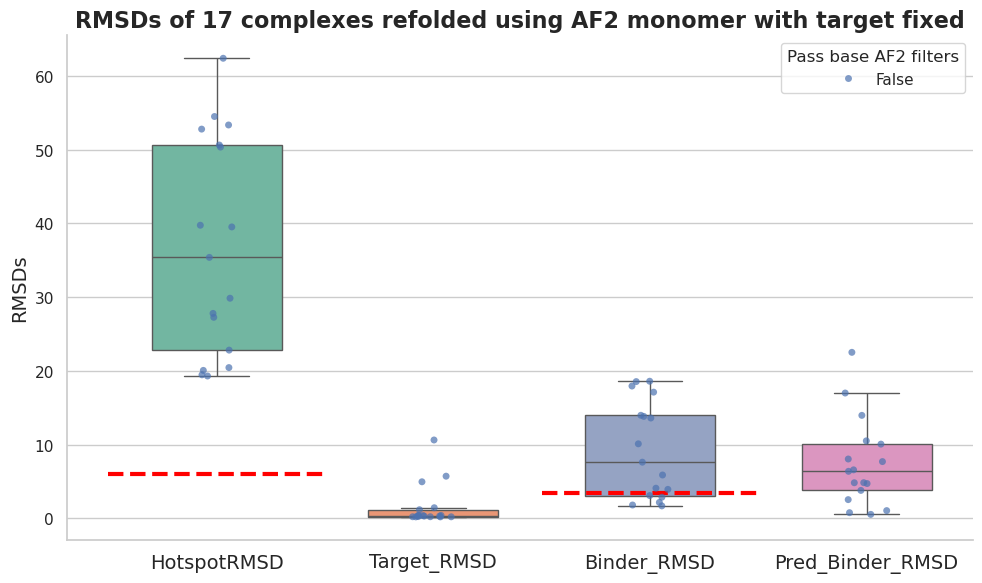

In [13]:
df_melted = rmsd_df.melt(id_vars='Pass_base_af2_filters',
                    value_vars=['HotspotRMSD', 'Target_RMSD', 'Binder_RMSD', 'Pred_Binder_RMSD'],
                    var_name='Metric', value_name='RMSD')

# Use a clean style
sns.set(style='whitegrid')

# Set up color palette for boxes
box_palette = sns.color_palette('Set2', 4)  # 4 soft, harmonious colors

plt.figure(figsize=(10, 6))

# Create the boxplot with custom palette
sns.boxplot(data=df_melted,
            x='Metric',
            y='RMSD',
            palette=box_palette,
            width=0.6,
            fliersize=0)  # hide outlier dots to reduce clutter

# Overlay the stripplot (points), colored by Pass_base_af2_filters
sns.stripplot(data=df_melted,
              x='Metric',
              y='RMSD',
              hue='Pass_base_af2_filters',
              dodge=True,
              jitter=True,
              marker='o',
              alpha=0.7,
              size=5)

# Mapping box positions to x-axis tick positions
metric_positions = {metric: i for i, metric in enumerate(df_melted['Metric'].unique())}

# Example: Add horizontal lines
plt.hlines(y=6, xmin=metric_positions['HotspotRMSD'] - 0.5, xmax=metric_positions['HotspotRMSD'] + 0.5,
           colors='red', linewidth=3, linestyles='--', label='_nolegend_')

plt.hlines(y=3.5, xmin=metric_positions['Binder_RMSD'] - 0.5, xmax=metric_positions['Binder_RMSD'] + 0.5,
           colors='red', linewidth=3, linestyles='--', label='_nolegend_')


# Titles and styling
plt.title('RMSDs of 17 complexes refolded using AF2 monomer with target fixed', fontsize=16, weight='bold')
plt.xlabel('')
plt.xticks(fontsize=14)
plt.ylabel('RMSDs', fontsize=14)
plt.legend(title='Pass base AF2 filters', loc='upper right', frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

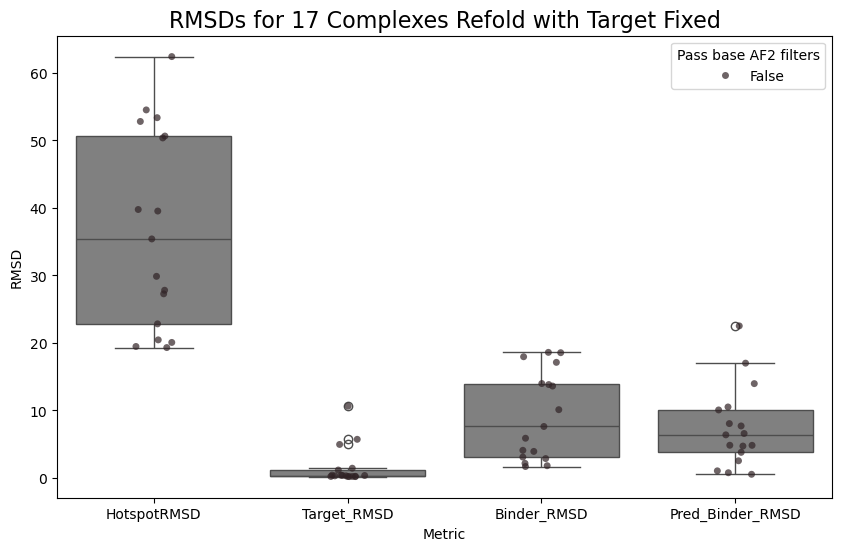

In [23]:

# Reshape DataFrame for seaborn
df_melted = rmsd_df.melt(id_vars='Pass_base_af2_filters',
                    value_vars=['HotspotRMSD', 'Target_RMSD', 'Binder_RMSD', 'Pred_Binder_RMSD'],
                    var_name='Metric', value_name='RMSD')
plt.figure(figsize=(10, 6))

# Create the boxplot
sns.boxplot(data=df_melted, x='Metric', y='RMSD', color='grey')

# Overlay the scatter points, colored by Pass_base_af2_filters
sns.stripplot(data=df_melted,
              x='Metric',
              y='RMSD',
              hue='Pass_base_af2_filters',
              dodge=True,
              color='pink',
              jitter=True,
              marker='o',
              alpha=0.7)

plt.title('RMSDs for 17 Complexes Refold with Target Fixed', fontsize=16)
plt.legend(title='Pass base AF2 filters')
plt.show()

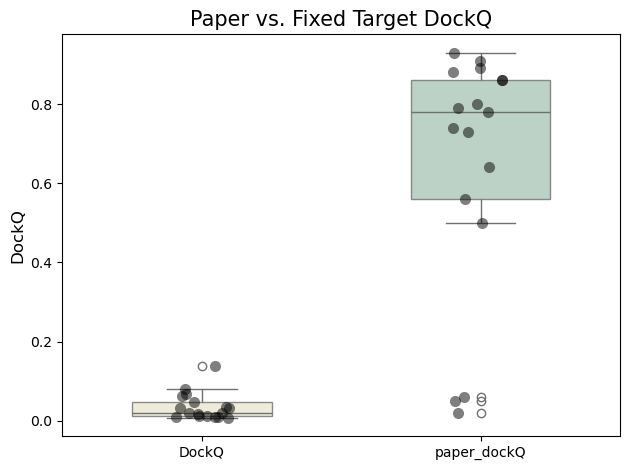

In [45]:
dockq_df = rmsd_df.melt(value_vars = ['DockQ', 'paper_dockQ'],
                        var_name = 'Type',
                        value_name='dockq')

box_colors = ['#EFECCA', '#A9CBB7']

sns.boxplot(data=dockq_df,
            x='Type',
            y='dockq',
            palette=box_colors,
            width=0.5,
            boxprops=dict(alpha=0.8))

sns.stripplot(data=dockq_df,
              x='Type',
              y='dockq',
              color='black',
              size=8,
              jitter=True,
              alpha=0.5)

plt.title('Paper vs. Fixed Target DockQ', fontsize=15)
plt.xlabel('')
plt.ylabel('DockQ', fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


In [38]:
# select binder from complex
# alphafold 5 model
# test all combination of fzd
# proxiy of affinity

# add dockQ comparsion
rmsd_df

,HotspotRMSD,Target_RMSD,Binder_RMSD,Pred_Binder_RMSD,DockQ,Pass_base_af2_filters,Best_complex_model,Best_binder_model,paper_dockQ
6u08,35.4,4.96,10.11,6.58,0.020091,False,2,4,0.93
5zng,50.64,0.24,7.62,6.38,0.012406,False,2,3,0.02
6a6i,29.86,0.21,1.81,1.05,0.031338,False,2,4,0.05
7nlj,52.8,0.22,2.16,0.54,0.010071,False,2,2,0.06
7aye,20.07,0.41,3.09,7.7,0.067035,False,2,3,0.88
6q76,27.27,0.4,2.87,4.72,0.034268,False,2,4,0.91
6if2,39.76,0.2,18.55,17.0,0.017444,False,2,4,0.74
7d2t,53.36,0.2,18.6,8.05,0.010033,False,2,2,0.78
7m5f,54.51,5.72,4.09,3.79,0.009432,False,1,2,0.89
6pnq,22.82,0.31,17.95,13.97,0.046048,False,1,1,0.56


In [ ]:
path = '/hpf/projects/mtyers/ningrui/NXBindCraft/myTrials/testRefold/tempFiles/dockq.csv'
dockq_df = pd.read_csv(path, index_col=0)

dict_keys(['aatype', 'atom_mask', 'atom_positions', 'cmap', 'grad', 'i_cmap', 'i_ptm', 'loss', 'losses', 'num_recycles', 'pae', 'plddt', 'prev', 'ptm', 'residue_index', 'seq', 'seq_pseudo', 'all', 'log'])

In [18]:
# dockq plot
rmsds_df = pd.read_csv('/hpf/projects/mtyers/ningrui/NXBindCraft/myTrials/testRefold/tempFiles/rmsds_17complex_dq.csv', index_col=0)
rmsds_df.rename(columns={'DockQ': 'mono_fixt_dockq'}, inplace=True)

DockQ_df = pd.concat([rmsds_df['mono_fixt_dockq'], dockq_df['mono_2seq_dockq'], 
                      dockq_df['multi_fixt_dockq'], dockq_df['multi_2seq_dockq'], 
                      rmsds_df['paper_dockQ']], axis=1)


In [19]:
DockQ_df

,mono_fixt_dockq,mono_2seq_dockq,multi_fixt_dockq,multi_2seq_dockq,paper_dockQ
6u08,0.020091,0.012670,0.091142,0.029076,0.93
5zng,0.012406,0.013078,0.021805,0.020065,0.02
6a6i,0.031338,0.055039,0.116924,0.271636,0.05
7nlj,0.010071,0.029777,0.023646,0.045292,0.06
7aye,0.067035,0.028588,0.120099,0.015468,0.88
6q76,0.034268,0.093991,0.019521,0.022625,0.91
6if2,0.017444,0.008443,0.039515,0.007170,0.74
7d2t,0.010033,0.009121,0.009436,0.009583,0.78
7m5f,0.009432,0.057830,0.036708,0.023794,0.89
6pnq,0.046048,0.006237,0.048264,0.009154,0.56


/localhd/17372646/ipykernel_1094332/1433731276.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted,


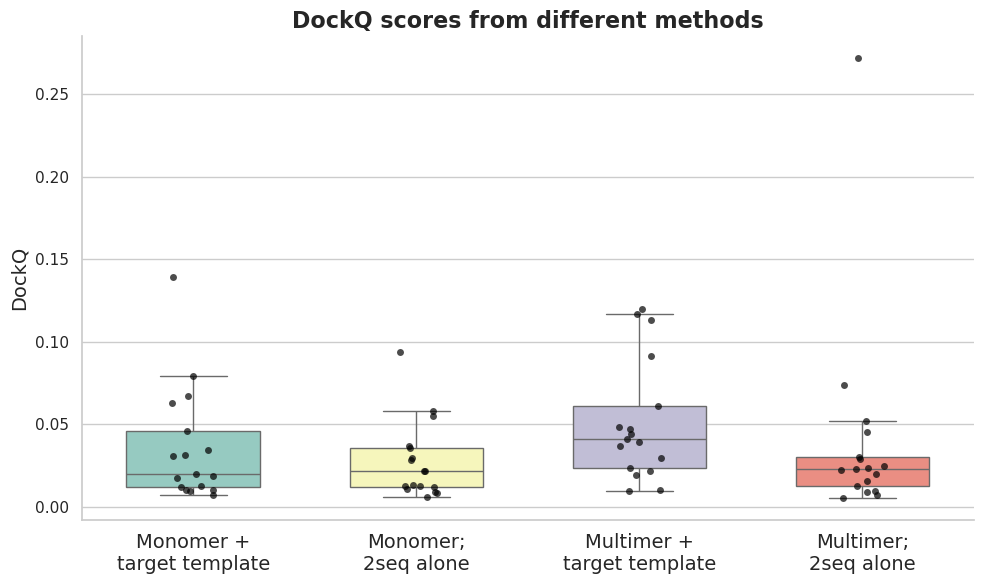

In [32]:
df_melted = DockQ_df.melt(value_vars = ['mono_fixt_dockq', 'mono_2seq_dockq', 'multi_fixt_dockq', 'multi_2seq_dockq'],
                        var_name = 'Type',
                        value_name='dockq')

# Use a clean style
sns.set(style='whitegrid')

# Set up color palette for boxes
box_palette = sns.color_palette("Set3", 4)

plt.figure(figsize=(10, 6))

# Create the boxplot with custom palette
sns.boxplot(data=df_melted,
            x='Type',
            y='dockq',
            palette=box_palette,
            width=0.6,
            fliersize=0)  # hide outlier dots to reduce clutter

# Overlay the stripplot (points), colored by Pass_base_af2_filters
sns.stripplot(data=df_melted,
              x='Type',
              y='dockq',
              dodge=True,
              color='black',
              jitter=True,
              marker='o',
              alpha=0.7,
              size=5)



# Titles and styling
plt.title('DockQ scores from different methods', fontsize=16, weight='bold')
plt.xlabel('')
new_labels = [
    'Monomer +\ntarget template',
    'Monomer;\n2seq alone',
    'Multimer +\ntarget template',
    'Multimer;\n2seq alone'
]
plt.xticks(ticks=range(len(new_labels)), labels=new_labels, fontsize=12)

plt.xticks(fontsize=14)
plt.ylabel('DockQ', fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()

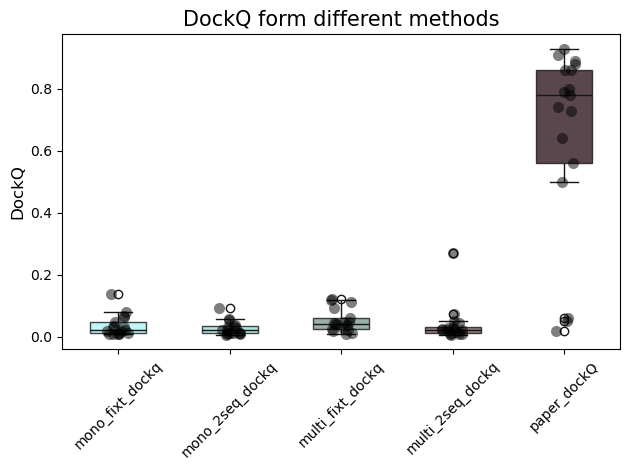

In [44]:
df = DockQ_df.melt(value_vars = ['mono_fixt_dockq', 'mono_2seq_dockq', 'multi_fixt_dockq', 'multi_2seq_dockq', 'paper_dockQ'],
                        var_name = 'Type',
                        value_name='dockq')

box_colors = ['#A8F9FF', '#9AE5E6', '#81A094', '#775B59', '#32161F']

sns.boxplot(data=df,
            x='Type',
            y='dockq',
            palette=box_colors,
            width=0.5,
            boxprops=dict(alpha=0.8))

sns.stripplot(data=df,
              x='Type',
              y='dockq',
              color='black',
              size=8,
              jitter=True,
              alpha=0.5)

plt.title('DockQ form different methods', fontsize=15)
plt.xlabel('')
plt.ylabel('DockQ', fontsize=12)

plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

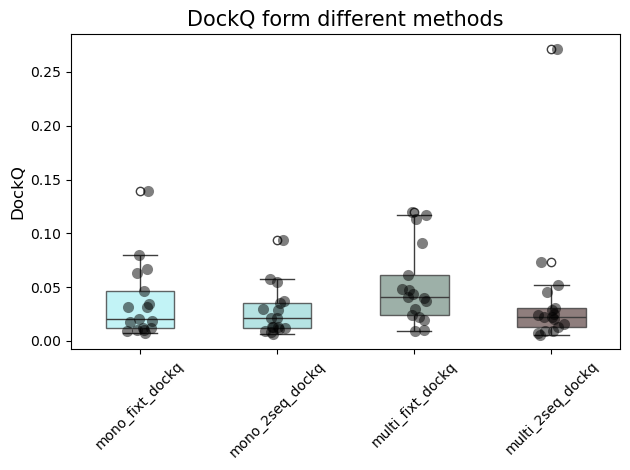

In [45]:
df = DockQ_df.melt(value_vars = ['mono_fixt_dockq', 'mono_2seq_dockq', 'multi_fixt_dockq', 'multi_2seq_dockq'],
                        var_name = 'Type',
                        value_name='dockq')

box_colors = ['#A8F9FF', '#9AE5E6', '#81A094', '#775B59']

sns.boxplot(data=df,
            x='Type',
            y='dockq',
            palette=box_colors,
            width=0.5,
            boxprops=dict(alpha=0.8))

sns.stripplot(data=df,
              x='Type',
              y='dockq',
              color='black',
              size=8,
              jitter=True,
              alpha=0.5)

plt.title('DockQ form different methods', fontsize=15)
plt.xlabel('')
plt.ylabel('DockQ', fontsize=12)

plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()